In [ ]:
import os
import requests
import pandas as pd
from astroquery.gaia import Gaia

class CreadorDatasetEspacial:
    def __init__(self, ruta_base="Dataset_Astro"):
        self.ruta_base = ruta_base
        self._preparar_carpetas()

    def _preparar_carpetas(self):
        """Crea la estructura de carpetas para el dataset de Machine Learning."""
        print("📁 Inicializando estructura del Dataset...")
        os.makedirs(self.ruta_base, exist_ok=True)
            
        # Carpeta para datos tabulares (Random Forest / Tabulares)
        os.makedirs(os.path.join(self.ruta_base, "Tabulares_Gaia"), exist_ok=True)
        print("   ✅ Carpetas listas.")

    def descargar_estrellas_gaia(self, limite_estrellas=5000):
        """Descarga un catálogo estelar de la ESA usando ADQL."""
        print("\n🛰️ INICIANDO MOTOR GAIA (Extracción Tabular ESA)...")
        print(f"   ⏳ Consultando {limite_estrellas} estrellas brillantes con temperatura conocida...")
        
        # Consulta ADQL: Pedimos ID, Coordenadas, Brillo, Color (BP-RP) y Temperatura
        consulta_adql = f"""
        SELECT TOP {limite_estrellas}
            source_id, ra, dec, phot_g_mean_mag as magnitud, 
            bp_rp as indice_color, teff_gspphot as temperatura_k
        FROM gaiadr3.gaia_source
        WHERE teff_gspphot IS NOT NULL 
          AND phot_g_mean_mag < 10.0
        ORDER BY phot_g_mean_mag ASC
        """
        
        try:
            # Ejecutar el trabajo en los servidores de Europa
            trabajo = Gaia.launch_job_async(consulta_adql)
            resultados = trabajo.get_results()
            
            # Convertir a un DataFrame de Pandas amigable para Machine Learning
            df_estrellas = resultados.to_pandas()
            
            ruta_csv = os.path.join(self.ruta_base, "Tabulares_Gaia", "estrellas_clasificacion.csv")
            df_estrellas.to_csv(ruta_csv, index=False)
            
            print(f"   ✅ Catálogo guardado en: {ruta_csv}")
            print(f"      (Contiene {len(df_estrellas)} estrellas listas para clasificar)")
            
        except Exception as e:
            print(f"   ⚠️ Error consultando el archivo Gaia: {e}")

# ==========================================================
# ⚙️ EJECUTOR MAESTRO DEL DATASET
# ==========================================================
if __name__ == "__main__":
    constructor = CreadorDatasetEspacial()
    
    
    # Extraer 1000 estrellas de Gaia
    constructor.descargar_estrellas_gaia(limite_estrellas=1000)
    
    print("\n🎉 ¡DATASET CONSTRUIDO CON ÉXITO! Listo para entrenar la IA.")

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
📁 Inicializando estructura del Dataset...
   ✅ Carpetas listas.

🚀 INICIANDO MOTOR NASA (Extracción de Imágenes)...
   🔭 Buscando imágenes de: Nebula...
   ✅ Descargadas 15 imágenes de Nebula.
   🔭 Buscando imágenes de: Jupiter...
   ✅ Descargadas 15 imágenes de Jupiter.
   🔭 Buscando imágenes de: Mars...
   ✅ Descargadas 15 imágenes de Mars.

🛰️ INICIANDO MOTOR GAIA (Extracción Tabular ESA)...
   ⏳ Consultando 1000 estrellas brillantes con temperatura conocida...
INFO: Query finished. [astroquery.utils.tap.core]
   ✅ Catálogo guardado en: Dataset_Astro\Tabulares_Gaia\estrellas_clasificacion.csv
      (Contiene 1000 estrellas listas para clasificar)

🎉 ¡DATASE

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Cargar los datos de Gaia (ignorando filas con datos faltantes)
df = pd.read_csv("Dataset_Astro/Tabulares_Gaia/estrellas_clasificacion.csv").dropna()

# 2. Física: Etiquetamos las estrellas según su temperatura termodinámica
def clasificar_espectro(temp):
    if temp > 7500: return "Estrella Caliente (Azul/Blanca)"
    elif temp > 5000: return "Estrella Templada (Amarilla)"
    else: return "Estrella Fría (Roja/Naranja)"

df['Clase_Espectral'] = df['temperatura_k'].apply(clasificar_espectro)

# 3. Preparar la IA: X (Lo que la IA ve) e y (Lo que tiene que adivinar)
X = df[['indice_color', 'magnitud']] # Solo le damos el color y el brillo
y = df['Clase_Espectral']

# Dividimos el dataset: 80% para estudiar, 20% para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Despertando a la IA Tabular (Árbol de Decisión)
arbol_ia = DecisionTreeClassifier(max_depth=4) # Le damos 4 niveles de profundidad para pensar
arbol_ia.fit(X_train, y_train) # ¡Aquí la IA está aprendiendo y haciendo matemáticas!

# 5. El Examen Final
predicciones = arbol_ia.predict(X_test)
precision = accuracy_score(y_test, predicciones)

print(f"🧠 Entrenamiento completado. Analizadas {len(X_train)} estrellas.")
print(f"🎯 Precisión de la IA en el examen ciego: {precision*100:.1f}%\n")

# Hacemos una prueba en vivo con los primeros 3 resultados
print("🔭 Prueba en vivo (Lo que adivinó vs La Realidad):")
for i in range(3):
    print(f"   IA dice: {predicciones[i]:<35} | Realidad: {y_test.iloc[i]}")

🧠 Entrenamiento completado. Analizadas 800 estrellas.
🎯 Precisión de la IA en el examen ciego: 90.0%

🔭 Prueba en vivo (Lo que adivinó vs La Realidad):
   IA dice: Estrella Caliente (Azul/Blanca)     | Realidad: Estrella Caliente (Azul/Blanca)
   IA dice: Estrella Caliente (Azul/Blanca)     | Realidad: Estrella Caliente (Azul/Blanca)
   IA dice: Estrella Fría (Roja/Naranja)        | Realidad: Estrella Fría (Roja/Naranja)


📸 ¡Gráfico del razonamiento de la IA guardado como 'Razonamiento_Arbol_Estelar.png'!


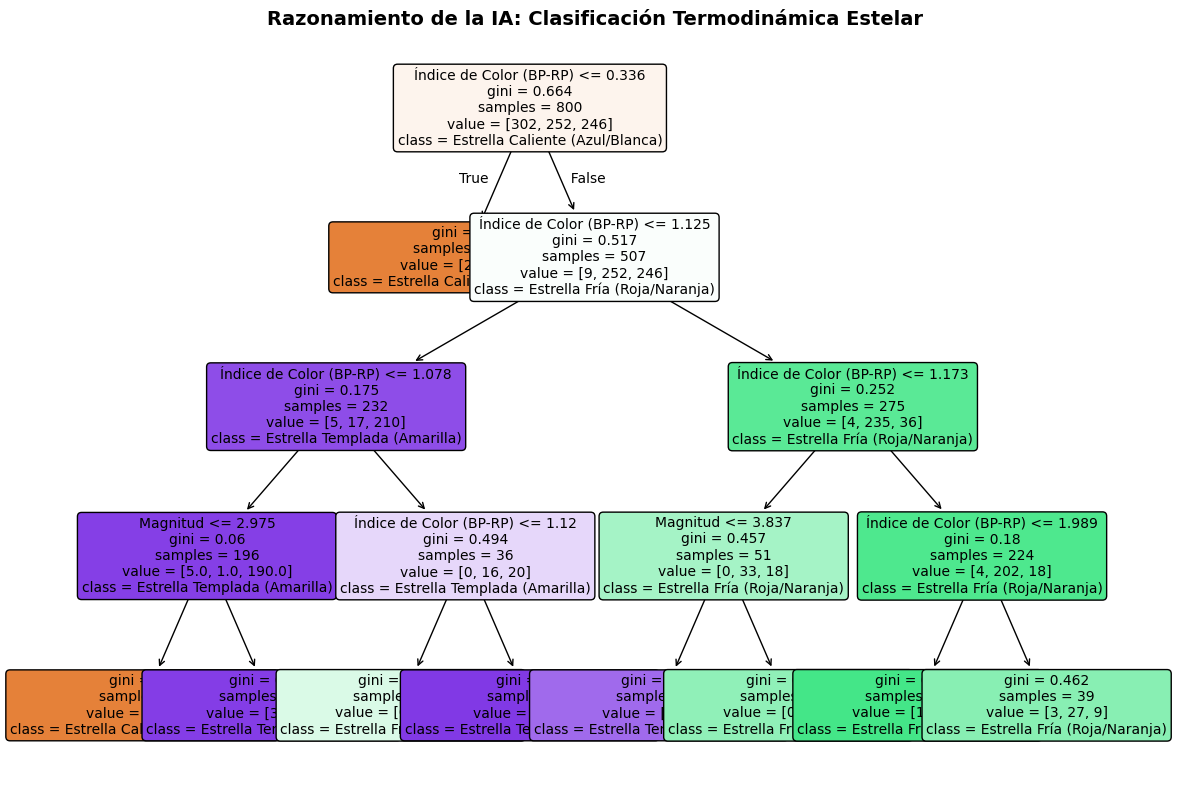

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 6. Dibujar el cerebro de la IA (XAI - Inteligencia Explicable)
plt.figure(figsize=(12, 8)) # Lienzo amplio

# Scikit-Learn coloreará automáticamente las clases gracias a filled=True
plot_tree(arbol_ia, 
          feature_names=['Índice de Color (BP-RP)', 'Magnitud'], 
          class_names=arbol_ia.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Razonamiento de la IA: Clasificación Termodinámica Estelar", fontsize=14, fontweight='bold')
plt.tight_layout()

# Guardar y mostrar
plt.savefig("Razonamiento_Arbol_Estelar.png", dpi=300)
print("📸 ¡Gráfico del razonamiento de la IA guardado como 'Razonamiento_Arbol_Estelar.png'!")
plt.show()